In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shahdelmasry23/telco-costumer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


# ***Imports***

In [2]:
import numpy as np # linear algebra
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV 
# Reproducibility
random_state = 42

# ***Load dataset***

## Dataset Description

This dataset contains information about telecommunications customers and their subscription services. The main objective is to predict whether a customer will leave the company or not. The target variable is `Churn`.

| Column             | Description                                                          |
| ------------------ | -------------------------------------------------------------------- |
| `customerID`       | Unique identifier for each customer.                                 |
| `gender`           | Customer's gender.                                                   |
| `SeniorCitizen`    | Indicates whether the customer is a senior citizen.                  |
| `Partner`          | Indicates whether the customer has a partner.                        |
| `Dependents`       | Indicates whether the customer has dependents.                       |
| `tenure`           | Number of months the customer has stayed with the company.           |
| `PhoneService`     | Indicates whether the customer has phone service.                    |
| `MultipleLines`    | Indicates whether the customer has multiple phone lines.             |
| `InternetService`  | Type of internet service used by the customer.                       |
| `OnlineSecurity`   | Indicates whether the customer has online security service.          |
| `OnlineBackup`     | Indicates whether the customer has online backup service.            |
| `DeviceProtection` | Indicates whether the customer has device protection service.        |
| `TechSupport`      | Indicates whether the customer has technical support service.        |
| `StreamingTV`      | Indicates whether the customer has a TV streaming service.           |
| `StreamingMovies`  | Indicates whether the customer has a movie streaming service.        |
| `Contract`         | Type of contract the customer has with the company.                  |
| `PaperlessBilling` | Indicates whether the customer uses paperless billing.               |
| `PaymentMethod`    | Payment method used by the customer.                                 |
| `MonthlyCharges`   | Amount charged to the customer each month.                           |
| `TotalCharges`     | Total amount charged to the customer during the subscription period. |
| `Churn`            | Target variable. Indicates whether the customer left the company.    |


In [3]:
data='/kaggle/input/datasets/shahdelmasry23/telco-costumer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df=pd.read_csv(data)
df.head() # View firts five rows(instance)'
df=pd.read_csv(data)

# ***Part 1 — Data Exploration(EDA)***

In [4]:
# View firts five rows(instance)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Veiw dimensions of dataset
#(Number of samples,Number of features)//(# Rows,# Columns)
df.shape

(7043, 21)

In [6]:
#Data type
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [7]:
#using info to see summery of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
#Missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
#Duplicate values
df.duplicated().sum()

np.int64(0)

In [10]:
#Descriptive statistics For numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [11]:
# use describe function on object dtype 
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [12]:
#Number of different values in textual texts
categorical_columns = df.select_dtypes(include='object').columns
#printing the unique values
for column in categorical_columns:
    print(column,df[column].unique())
    print(f"Number of unique values: {df[column].nunique()}")
    print("*"*50)

customerID ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
Number of unique values: 7043
**************************************************
gender ['Female' 'Male']
Number of unique values: 2
**************************************************
Partner ['Yes' 'No']
Number of unique values: 2
**************************************************
Dependents ['No' 'Yes']
Number of unique values: 2
**************************************************
PhoneService ['No' 'Yes']
Number of unique values: 2
**************************************************
MultipleLines ['No phone service' 'No' 'Yes']
Number of unique values: 3
**************************************************
InternetService ['DSL' 'Fiber optic' 'No']
Number of unique values: 3
**************************************************
OnlineSecurity ['No' 'Yes' 'No internet service']
Number of unique values: 3
**************************************************
OnlineBackup ['Yes' 'No' 'No internet serv

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


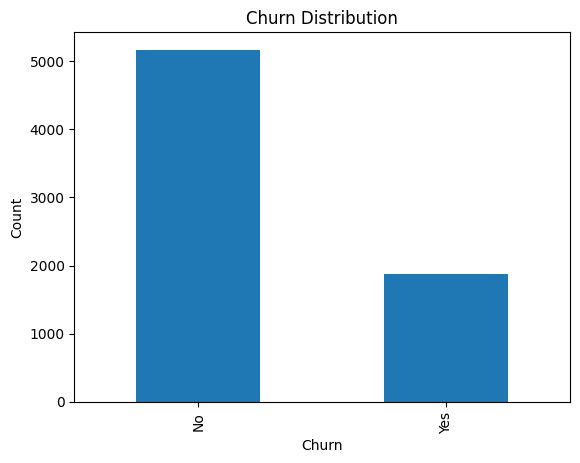

In [13]:
# Target Churn distribution.
print(df["Churn"].value_counts(normalize=True)*100)#normalize=True--->To Calculate the percentage for each value


df["Churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

In [14]:
#Percentage of customers who left the company.
print("Percentage of customers who left the company: ",df['Churn'].value_counts(normalize=True)['Yes']* 100)

Percentage of customers who left the company:  26.536987079369588


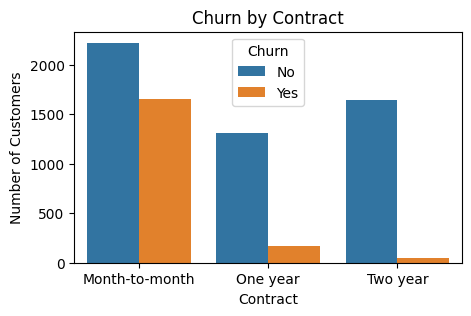

In [15]:
#Contract relationship with Churn
plt.figure(figsize=(5,3))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn by Contract")
plt.xlabel("Contract")
plt.ylabel("Number of Customers")
plt.show()

#### Contract relationship with Churn 
   * We conclude that the longer the contract period with the company, the greater the chance of the customer remaining with the company.

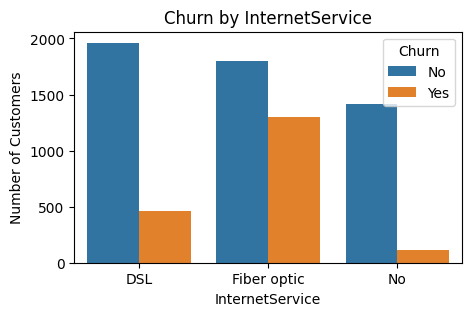

In [16]:
#InternetService's relationship with Churn
plt.figure(figsize=(5,3))
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("Churn by InternetService")
plt.xlabel("InternetService")
plt.ylabel("Number of Customers")
plt.show()

#### InternetService's relationship with Churn
  * We conclude that customers with DSL internet service or no internet service are more likely to stay than those with fiber optic internet service.

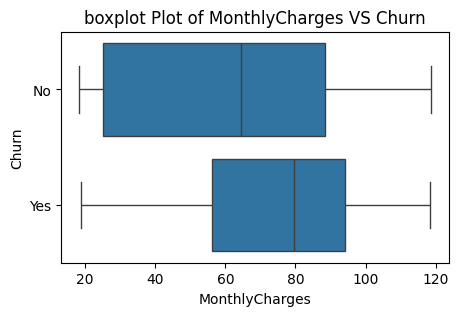

In [17]:
# MonthlyCharges compares customers who quit and those who did not. By using Box Plot Because of comparing a numerical variable between categories
plt.figure(figsize=(5, 3))
sns.boxplot(x=df["MonthlyCharges"], y=df["Churn"])
plt.title("boxplot Plot of MonthlyCharges VS Churn")
plt.xlabel("MonthlyCharges")
plt.ylabel("Churn")
plt.show()

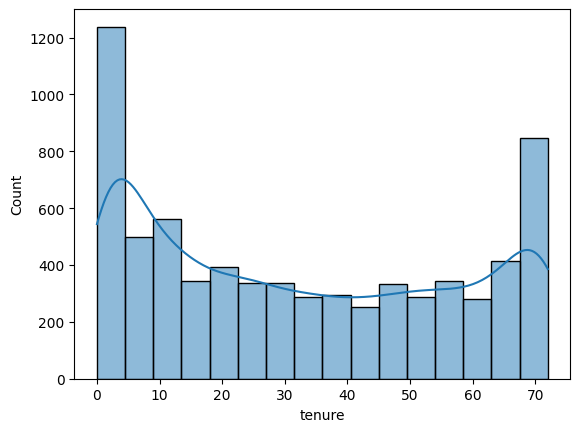

In [18]:
#Distribution of tenure.By using Histplot Becuase it use to Know the distribution of a numerical variable
sns.histplot(df["tenure"], kde=True)
plt.show()

# ***Part 2 — Data Cleaning and Preprocessing***